# XGBoost Calibration and Brier Score Optimization
In this notebook, we'll train our XGBoost model on the engineered dataset to find the most accurate $P(Win)$. Our primary evaluation metric is the **Brier Score** which evaluates calibration (how close probability estimations are to reality).
A lower Brier Score is better. Perfect accuracy is 0.0. Clueless guessing (50/50 every time) is 0.25. Our target is < 0.21.

In [13]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, accuracy_score, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Load V2 processed features with SOS!
df = pd.read_csv('../data/processed/model_features_v2.csv')

### Temporal Train/Test Split
It is critical to use a chronological split rather than a random split. This ensures we are "backtesting" on future games using only past data, mirroring real-world predictive modeling.

In [14]:
# Since the dataframe is created chronologically, we can just split by index
split_index = int(len(df) * 0.8)

# We also need to encode 'side' (Blue / Red)
df['is_blue_side'] = (df['side'] == 'Blue').astype(int)

# Use the new SOS adjusted features
features = [
    'team_elo_pre', 'opp_elo_pre', 'expected_win_prob', 'is_blue_side',
    'roll5_opp_elo_pre', # NEW: Historical SOS 
    'roll5_adj_golddiffat15', 'roll5_adj_xpdiffat15', 'roll5_adj_csdiffat15', 
    'roll5_adj_firstblood', 'roll5_adj_firstdragon', 'roll5_adj_firstherald', 
    'roll5_adj_firsttower', 'roll5_adj_firstbaron', 'roll5_adj_dpm', 'roll5_adj_vspm'
]
target = 'result'

X = df[features]
y = df[target]

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_test)}")

Training set size: 33237
Validation set size: 8310


### Training the XGBoost Calibrator

In [15]:
# We use binary:logistic to output calibrated probabilities, optimized for logloss
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.05,
    max_depth=4,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-logloss:0.68784
[50]	validation_0-logloss:0.63729
[100]	validation_0-logloss:0.63643
[150]	validation_0-logloss:0.63700
[200]	validation_0-logloss:0.63784
[250]	validation_0-logloss:0.63839
[299]	validation_0-logloss:0.63896


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Evaluation: Brier Score & Feature Importance

In [16]:
preds_proba = xgb_model.predict_proba(X_test)[:, 1]
preds_class = xgb_model.predict(X_test)

brier = brier_score_loss(y_test, preds_proba)
acc = accuracy_score(y_test, preds_class)
auc = roc_auc_score(y_test, preds_proba)

print(f"\n--- Model Performance ---")
print(f"Brier Score: {brier:.4f}  (Target: < 0.21)")
print(f"Accuracy:    {acc*100:.2f}%")
print(f"AUC-ROC:     {auc:.4f}")

# Baseline ELO model Brier Score for context
elo_brier = brier_score_loss(y_test, X_test['expected_win_prob'])
print(f"\nBaseline ELO Brier Score: {elo_brier:.4f}")
print(f"Improvement from XGBoost context layer: {(elo_brier - brier):.4f}")

# Feature Importance
importance = pd.DataFrame({'feature': features, 'importance': xgb_model.feature_importances_})
importance = importance.sort_values('importance', ascending=False)
print("\n--- Top 5 Features ---")
print(importance.head(5))


--- Model Performance ---
Brier Score: 0.2245  (Target: < 0.21)
Accuracy:    62.84%
AUC-ROC:     0.6819

Baseline ELO Brier Score: 0.2267
Improvement from XGBoost context layer: 0.0022

--- Top 5 Features ---
                feature  importance
2     expected_win_prob    0.391585
3          is_blue_side    0.080121
1           opp_elo_pre    0.065822
0          team_elo_pre    0.064932
7  roll5_adj_csdiffat15    0.053079


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Apply Isotonic Calibration directly on the training set using 5-fold CV to train the Platt scaler!
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='logloss',
    learning_rate=0.05, max_depth=4, n_estimators=100, 
    subsample=0.8, colsample_bytree=0.8, random_state=42
)

calibrated_clf = CalibratedClassifierCV(estimator=xgb_base, method='isotonic', cv=5)
calibrated_clf.fit(X_train, y_train)

# Predict with calibrated model
preds_proba_calib = calibrated_clf.predict_proba(X_test)[:, 1]
brier_calib = brier_score_loss(y_test, preds_proba_calib)

print(f"Calibrated Brier Score: {brier_calib:.4f}")

Calibrated Brier Score: 0.2233


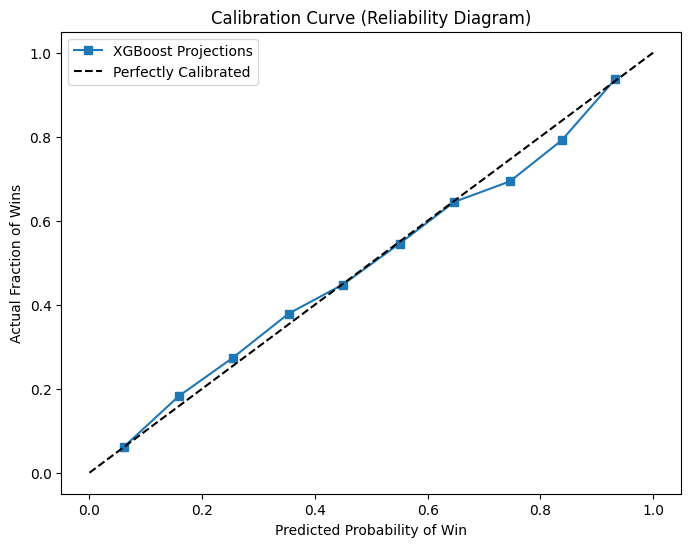

In [5]:
# Let's visualize the Calibration Curve to see where the model is over/under confident
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, preds_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="XGBoost Projections")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.ylabel("Actual Fraction of Wins")
plt.xlabel("Predicted Probability of Win")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend()
plt.show()